In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from astropy.io import fits
import photutils
import os
import pandas as pd
from astropy.cosmology import FlatLambdaCDM
import astropy.constants as const
import astropy.units as u
# import statmorph
from astropy.visualization import simple_norm
# from statmorph.utils.image_diagnostics import make_figure
from photutils.background import Background2D, MedianBackground
from astropy.convolution import convolve, Gaussian2DKernel
from photutils.segmentation import make_2dgaussian_kernel
from photutils.segmentation import detect_sources
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from photutils.segmentation import deblend_sources
from photutils.segmentation import SourceFinder
from photutils.segmentation import SourceCatalog
from astropy.visualization import LogStretch
from photutils.isophote import EllipseGeometry
from photutils.aperture import EllipticalAperture
from astropy.stats import sigma_clipped_stats
from photutils.aperture import ApertureStats, CircularAperture
from photutils.datasets import make_4gaussians_image
from photutils.aperture import aperture_photometry
from photutils.isophote import Ellipse
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.visualization import simple_norm
from scipy.optimize import leastsq
from scipy.optimize import fsolve
from scipy.optimize import minimize
import re
from astropy.modeling import models, fitting
from astropy.io import fits
from astropy.modeling.models import custom_model
from astropy.convolution import convolve_models
from scipy.signal import fftconvolve
from astropy.visualization import (
    ImageNormalize,
    MinMaxInterval,
    LogStretch,
    HistEqStretch,
    LinearStretch,
    ZScaleInterval,
)
from photutils.isophote import Ellipse, EllipseGeometry
import matplotlib.ticker as ticker
import copy
import sys
import os
import math
import logging
# from basicfunc import *
import glob
from photutils.centroids import centroid_quadratic
from photutils.profiles import RadialProfile
from astropy.table import Table
# import galsim
def abmag_to_nJy(abmag, delta_abmag=0.0):
    # 计算光通量密度（Jy）
    F_Jy = 10**(-0.4 * (abmag + 48.6))
    # 转换为 nJy
    F_nJy = F_Jy * 1e9 * 1e23
    # 计算误差传递
    delta_F_nJy = F_nJy * np.log(10) * 0.4 * delta_abmag
    return F_nJy, delta_F_nJy


plt.style.use('/Users/zijianzhang/Astro_Data/paper.mplstyle')

filter_wavelengths = {
    'F070W': 0.7, 'F090W': 0.9, 'F115W': 1.15,  'F150W': 1.5, 'F164N': 1.64, 'F105W': 1.055025, 'F125W': 1.248607, 'F140W': 1.392321, 'F160W': 1.537034, 
     'F200W': 2.0,'F277W': 2.77,  'F162M': 1.62, 'F182M': 1.82, "F187N": 1.87,
    'F300M': 3.0, 'F335M': 3.35, 'F356W': 3.56, 'F360M': 3.6, 'F210M': 2.1, 'F250M': 2.5, 'F410M': 4.1, 'F430M': 4.3, 'F140M': 1.4, 
    'F444W': 4.44, 'F460M': 4.6, 'F480M': 4.8, 'F435W': 0.435, 'F606W': 0.606, 'F775W': 0.775, 'F814W': 0.814
}

tab_hst_jwst_combined = Table.read('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/catalog/venus_slice_hst_combine_lenslrd_phot.fits')

Duplicate key in file '/Users/zijianzhang/Astro_Data/paper.mplstyle', line 23 ('axes.linewidth : 1.5')


In [2]:
imagelist = ['2.1', '2.2', '2.3', '2.4', '2.5']
typelist = ['sersiconlypsf', 'psf', 'psf', 'psf', 'psfsersic']

finalnJylist = []
finalnJyerrlist = []

# 自定义 upper limits for 2.2 SW bands
upper_limit_flux = np.array([5, 6, 6, 3, 5, 5])  # nJy
upper_limit_err  = np.array([4.9, 5.9, 5.9, 2.9, 4.9, 4.9])   # nJy

for image, phottype in zip(imagelist, typelist):
    os.chdir(f'/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/cutout_image/{image}/')

    # 判断 photometry 类型
    if 'sersic' in phottype:
        ttype = 'sersic'
    else:
        ttype = 'psf'

    info_dict = {
        f'{image}_result_SW_{ttype}.fits': ['F090W', 'F115W', 'F150W','F150W2', 'F200W', 'F210M'],
        f'{image}_result_LW_{ttype}.fits': ['F277W', 'F300M', 'F322W2','F356W', 'F410M', 'F444W']
    }

    psf_mags, psf_mags_err = [], []
    sersic_mags, sersic_mags_err = [], []

    for result_name, bandnames in info_dict.items():
        hdu = fits.open(result_name)
        psf_mag_key = ['1_MAG_' + i for i in bandnames]
        sersic_mag_key = ['2_MAG_' + i for i in bandnames]

        for i in range(len(bandnames)):
            psf_mag = hdu[8].header[psf_mag_key[i]].split(' ')[0].replace('*', '')   
            psf_err = hdu[8].header[psf_mag_key[i]].split(' ')[2].replace('*', '')
            psf_mags.append(float(psf_mag))
            psf_mags_err.append(float(psf_err))

            if ttype == 'sersic':
                sersic_mag = hdu[8].header[sersic_mag_key[i]].split(' ')[0].replace('*', '')
                sersic_err = hdu[8].header[sersic_mag_key[i]].split(' ')[2].replace('*', '')
                sersic_mags.append(float(sersic_mag))
                sersic_mags_err.append(float(sersic_err))

    # 转换为 nJy
    psf_mags = np.array(psf_mags)
    psf_mags_err = np.array(psf_mags_err)
    psf_nJy, psf_nJyerr = abmag_to_nJy(psf_mags, psf_mags_err)
    sersic_mags = np.array(sersic_mags)
    sersic_mags_err = np.array(sersic_mags_err)
    sersic_nJy, sersic_nJyerr = abmag_to_nJy(sersic_mags, sersic_mags_err)

    # === 特殊情况替换 ===
    if image == '2.2':
        # 替换前五个（SW bands）
        psf_nJy[:6] = upper_limit_flux
        psf_nJyerr[:6] = upper_limit_err
        if ttype == 'sersic':
            sersic_nJy[:6] = upper_limit_flux
            sersic_nJyerr[:6] = upper_limit_err

    # === 合并结果 ===
    if phottype in ['psf', 'sersiconlypsf']:
        finalnJy = psf_nJy
        finalnJy_err = psf_nJyerr
    elif phottype == 'psfsersic':
        finalnJy = psf_nJy + sersic_nJy
        finalnJy_err = np.sqrt(psf_nJyerr**2 + sersic_nJyerr**2)

    finalnJylist.append(finalnJy)
    finalnJyerrlist.append(finalnJy_err)

In [3]:
bands = ['F090W', 'F115W', 'F150W', 'F150W2','F200W', 'F210M',
         'F277W', 'F300M','F322W2','F356W', 'F410M', 'F444W']

# 初始化 Table 的列
data_dict = {'ID': imagelist}

# 将每个 band 的 flux 和 error 组织进表格
for i, band in enumerate(bands):
    data_dict[f'f_{band}'] = [finalnJylist[j][i] for j in range(len(imagelist))]
    data_dict[f'e_{band}'] = [finalnJyerrlist[j][i] for j in range(len(imagelist))]

# 构建 astropy Table
tab = Table(data_dict)

# 输出查看
# print(tab)



def read_lens_data(filename):
    """
    读取 lensing 参数文件并解析为字典。
    每个系统像 (如 4.1, 16.2) 的数据结构：
        {'x': (value, +err, -err), 'y': (...), 'mu': (...), 'dt': (...)}
    """
    data = {}

    pattern = re.compile(
        r'(?P<param>[xy]|mu|dt)\((?P<id>[\d\.]+)\).*?([ \t]+)?(?P<value>[-\d\.]+)\^\{\+(?P<errp>[\d\.]+)\}_\{\-(?P<errm>[\d\.]+)\}'
    )

    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            m = pattern.search(line)
            if m:
                param = m.group('param')
                if param == 'dt':  # 处理 dt(4.1)[day] 这种情况
                    param = 'dt'
                img_id = m.group('id')
                val = float(m.group('value'))
                errp = float(m.group('errp'))
                errm = float(m.group('errm'))

                if img_id not in data:
                    data[img_id] = {}
                data[img_id][param] = (val, errp, errm)
    return data

lens_data_file = '/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/lensing_model/rj2211_glafic_v0p9_summary_mu_td_lrds.dat'

lens_dict = read_lens_data(lens_data_file)

In [4]:
tab_hst_jwst_combined

ID_2,RA_1_1,DEC_1_1,id_2_1,RA_2_1,DEC_2_1,f_F090W,e_F090W,f_F115W,e_F115W,f_F150W2,e_F150W2,f_F150W,e_F150W,f_F200W,e_F200W,f_F210M,e_F210M,f_F277W,e_F277W,f_F300M,e_F300M,f_F322W2,e_F322W2,f_F356W,e_F356W,f_F410M,e_F410M,f_F444W,e_F444W,Separation_1,id_1_2,ra_1_2,dec_1_2,f435w_mag,f435w_magerr_1,f435w_flux,f435w_fluxerr,f435w_fluxnJy,f435w_fluxnJyerr,f435w_sig,f606w_mag,f606w_magerr_1,f606w_flux,f606w_fluxerr,f606w_fluxnJy,f606w_fluxnJyerr,f606w_sig,f814w_mag,f814w_magerr_1,f814w_flux,f814w_fluxerr,f814w_fluxnJy,f814w_fluxnJyerr,f814w_sig,f105w_mag,f105w_magerr_1,f105w_flux,f105w_fluxerr,f105w_fluxnJy,f105w_fluxnJyerr,f105w_sig,f125w_mag,f125w_magerr_1,f125w_flux,f125w_fluxerr,f125w_fluxnJy,f125w_fluxnJyerr,f125w_sig,f140w_mag,f140w_magerr_1,f140w_flux,f140w_fluxerr,f140w_fluxnJy,f140w_fluxnJyerr,f140w_sig,f160w_mag,f160w_magerr_1,f160w_flux,f160w_fluxerr,f160w_fluxnJy,f160w_fluxnJyerr,f160w_sig,ra_2_2,dec_2_2,f125w_fluxerr_njy,f125w_magerr_2,f140w_fluxerr_njy,f140w_magerr_2,f105w_fluxerr_njy,f105w_magerr_2,f606w_fluxerr_njy,f606w_magerr_2,f435w_fluxerr_njy,f435w_magerr_2,f814w_fluxerr_njy,f814w_magerr_2,f160w_fluxerr_njy,f160w_magerr_2,ID_2_2,Separation_2,Separation_1a,f125w_sig_new,f140w_sig_new,f105w_sig_new,f606w_sig_new,f435w_sig_new,f814w_sig_new,f160w_sig_new,F435W_CIRC1,F435W_CIRC1_e,F606W_CIRC1,F606W_CIRC1_e,F814W_CIRC1,F814W_CIRC1_e,ID,RA,DEC,X,Y,bbox_xmin,bbox_xmax,bbox_ymin,bbox_ymax,area,semimajor_sigma,semiminor_sigma,orientation,eccentricity,min_value,max_value,local_background,kron_radius,Gini,det_segment_flux,det_segment_fluxerr,det_kron_flux,det_kron_fluxerr,F090W_CIRC1,F090W_CIRC1_e,F090W_CIRC1_en,F090W_CIRC2,F090W_CIRC2_e,F090W_CIRC2_en,F090W_CIRC3,F090W_CIRC3_e,F090W_CIRC3_en,F090W_CIRC4,F090W_CIRC4_e,F090W_CIRC4_en,F090W_CIRC5,F090W_CIRC5_e,F090W_CIRC5_en,F090W_CIRC6,F090W_CIRC6_e,F090W_CIRC6_en,F090W_KRON,F090W_KRON_S,F090W_KRON_S_e,F090W_KRON_S_en,F090W_KRON_e,F090W_KRON_en,F090W_local_background,F090W_segment_flux,F090W_segment_flux_err,F115W_CIRC1,F115W_CIRC1_e,F115W_CIRC1_en,F115W_CIRC2,F115W_CIRC2_e,F115W_CIRC2_en,F115W_CIRC3,F115W_CIRC3_e,F115W_CIRC3_en,F115W_CIRC4,F115W_CIRC4_e,F115W_CIRC4_en,F115W_CIRC5,F115W_CIRC5_e,F115W_CIRC5_en,F115W_CIRC6,F115W_CIRC6_e,F115W_CIRC6_en,F115W_KRON,F115W_KRON_S,F115W_KRON_S_e,F115W_KRON_S_en,F115W_KRON_e,F115W_KRON_en,F115W_local_background,F115W_segment_flux,F115W_segment_flux_err,F150W2_CIRC1,F150W2_CIRC1_e,F150W2_CIRC1_en,F150W2_CIRC2,F150W2_CIRC2_e,F150W2_CIRC2_en,F150W2_CIRC3,F150W2_CIRC3_e,F150W2_CIRC3_en,F150W2_CIRC4,F150W2_CIRC4_e,F150W2_CIRC4_en,F150W2_CIRC5,F150W2_CIRC5_e,F150W2_CIRC5_en,F150W2_CIRC6,F150W2_CIRC6_e,F150W2_CIRC6_en,F150W2_KRON,F150W2_KRON_S,F150W2_KRON_S_e,F150W2_KRON_S_en,F150W2_KRON_e,F150W2_KRON_en,F150W2_local_background,F150W2_segment_flux,F150W2_segment_flux_err,F150W_CIRC1,F150W_CIRC1_e,F150W_CIRC1_en,F150W_CIRC2,F150W_CIRC2_e,F150W_CIRC2_en,F150W_CIRC3,F150W_CIRC3_e,F150W_CIRC3_en,F150W_CIRC4,F150W_CIRC4_e,F150W_CIRC4_en,F150W_CIRC5,F150W_CIRC5_e,F150W_CIRC5_en,F150W_CIRC6,F150W_CIRC6_e,F150W_CIRC6_en,F150W_KRON,F150W_KRON_S,F150W_KRON_S_e,F150W_KRON_S_en,F150W_KRON_e,F150W_KRON_en,F150W_local_background,F150W_segment_flux,F150W_segment_flux_err,F200W_CIRC1,F200W_CIRC1_e,F200W_CIRC1_en,F200W_CIRC2,F200W_CIRC2_e,F200W_CIRC2_en,F200W_CIRC3,F200W_CIRC3_e,F200W_CIRC3_en,F200W_CIRC4,F200W_CIRC4_e,F200W_CIRC4_en,F200W_CIRC5,F200W_CIRC5_e,F200W_CIRC5_en,F200W_CIRC6,F200W_CIRC6_e,F200W_CIRC6_en,F200W_KRON,F200W_KRON_S,F200W_KRON_S_e,F200W_KRON_S_en,F200W_KRON_e,F200W_KRON_en,F200W_local_background,F200W_segment_flux,F200W_segment_flux_err,F210M_CIRC1,F210M_CIRC1_e,F210M_CIRC1_en,F210M_CIRC2,F210M_CIRC2_e,F210M_CIRC2_en,F210M_CIRC3,F210M_CIRC3_e,F210M_CIRC3_en,F210M_CIRC4,F210M_CIRC4_e,F210M_CIRC4_en,F210M_CIRC5,F210M_CIRC5_e,F210M_CIRC5_en,F210M_CIRC6,F210M_CIRC6_e,F210M_CIRC6_en,F210M_KRON,F210M_KRON_S,F210M_KRON_S_e,F210M_KRON_S_en,F210M_KRON_e,F210M_KRON_en,F210M_local_background,F210M_segment_flux,F210M_segment_flux_err,F277W_CIRC1

In [5]:
# 要替换的 ID 列表
target_ids = [2.3, 2.4, 2.5]

# 对于每个目标 ID，逐个替换 flux 和 error 列
for target_id in target_ids:
    # 找出 tab 和 tab_hst_jwst_combined 中该 ID 的行索引
    mask_tab = tab['ID'] == str(target_id)
    mask_ref = tab_hst_jwst_combined['ID_2'] == str(target_id)

    if not any(mask_tab):
        print(f"⚠️ ID {target_id} 不在 tab 中，跳过。")
        continue
    if not any(mask_ref):
        print(f"⚠️ ID {target_id} 不在 tab_hst_jwst_combined 中，跳过。")
        continue

     # 找到行号（整型索引）
    i_tab = np.where(mask_tab)[0][0]
    i_ref = np.where(mask_ref)[0][0]

    # 替换各 band 的 flux 和 error
    for band in bands:
        tab[f'f_{band}'][i_tab] = tab_hst_jwst_combined[f'f_{band}'][i_ref]
        tab[f'e_{band}'][i_tab] = tab_hst_jwst_combined[f'e_{band}'][i_ref]

print("✅ 替换完成！")

✅ 替换完成！


2.1
2.2
2.3
2.4
2.5


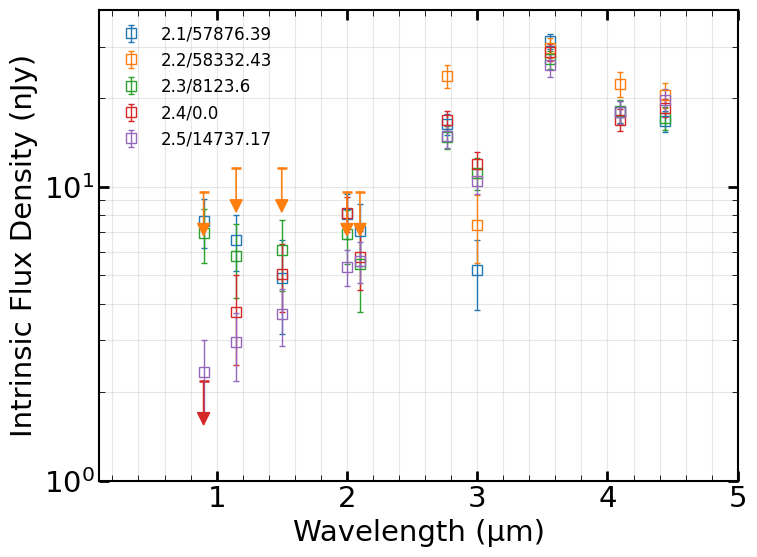

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
color_cycle = cycle(plt.cm.tab10.colors)  # 给不同像用不同颜色

tab_hst_jwst_combined = tab
mask = np.array(['.' in i for i in tab_hst_jwst_combined['ID']])
sel_tab = tab_hst_jwst_combined[mask]
mu_errs = [0.05, 0.07, 0.15, 0.12, 0.57]  # 依次对应 1.1,1.2,1.3,1.4
# 筛选 system-1
# mask = np.array(['2.1' in i or '2.3' in i or '2.4' in i  or '2.5' in i for i in tab_hst_jwst_combined['ID_2']])
mask = np.array(['2.1' in i or '2.2' in i or '2.3' in i or '2.4' in i  or '2.5' in i for i in tab_hst_jwst_combined['ID']])
sel_tab = tab_hst_jwst_combined[mask]
jwstbands = [ 'F277W',  'F356W', 'F150W','F090W', 'F115W',  'F200W', 'F210M', 'F300M', 'F410M', 'F444W']
wave_jwst = np.array([ 2.77,  3.56, 1.50, 0.9, 1.15,  2.00, 2.10,3.00,4.10, 4.44]) * u.um

# jwstbands = ['F090W', 'F115W', 'F150W','F150W2', 'F200W', 'F210M', 'F277W',  'F300M', 'F322W2','F356W', 'F410M', 'F444W']
# wave_jwst = np.array([0.9, 1.15, 1.50, 1.50, 2.00, 2.10, 2.77, 3.00, 3.22, 3.56, 4.10, 4.44])
fluxkey_jwst = ['f_' + band.upper() for band in jwstbands] 
fluxerr_key_jwst = ['e_' + band.upper()  for band in jwstbands] 


# AB mag 转 nJy
def mag_to_njy(mag):
    return 10**((31.4 - mag) / 2.5)

color_cycle = cycle(plt.cm.tab10.colors)

plotted_labels = set()  # 避免重复 legend
plt.figure(figsize=(8, 6))
color_cycle = cycle(plt.cm.tab10.colors)
plotted_labels = set()

ax = plt.gca()

jwstflux_list = []
jwstfluxerr_list = []

jwst_sed_mag_list = []
jwst_sed_magerr_list = []
jwst_sed_uplim_mask_list = []

for col in sel_tab:
    name = col['ID']
    print(name)
    color = next(color_cycle)
    img_idx = int(name.split('.')[1])

    mu = lens_dict[f'10.{img_idx}']["mu"][0]
    mu_err = np.max([np.abs(lens_dict[f'10.{img_idx}']["mu"][2]), np.abs(lens_dict[f'10.{img_idx}']["mu"][1])])
    mu_abs = np.abs(mu)
    td = lens_dict[f'10.{img_idx}']["dt"][0]

    jwst_flux      = np.array([col[k] for k in fluxkey_jwst], dtype=float)
    jwst_flux_err  = np.array([col[k] for k in fluxerr_key_jwst], dtype=float)

    # 放大率修正
    jwst_flux_corr = jwst_flux / mu_abs
    jwst_flux_err_corr = jwst_flux_err / mu_abs
    jwst_flux_err_corr = jwst_flux_corr * np.sqrt((jwst_flux_err/jwst_flux)**2 + (mu_err/mu)**2)

    # 信噪比
    snr = jwst_flux_corr / jwst_flux_err_corr

    # 检测点 & 上限掩膜
    det_mask = snr >= 2
    uplim_mask = snr < 2

    factor = 1  # 归一因子，可自行调整

    def flux_to_mag(flux):
        return 31.4 - 2.5 * np.log10(flux)

    # 转换成 mag
    mags = np.zeros_like(jwst_flux_corr)
    magerrs = np.zeros_like(jwst_flux_err_corr)

    # 对检测点：正常转换
    mags[det_mask] = flux_to_mag(jwst_flux_corr[det_mask])
    magerrs[det_mask] = (2.5 / np.log(10)) * (jwst_flux_err_corr[det_mask] / jwst_flux_corr[det_mask])

    # 对上限点：mag = 2σ flux 对应的 magnitude，误差设为 NaN
    upper_mag = flux_to_mag(jwst_flux_err_corr * 2)
    mags[uplim_mask] = upper_mag[uplim_mask]
    magerrs[uplim_mask] = np.nan   # 上限无误差

    # 保存该 epoch 的 SED 到列表，用于之后在另一个脚本中画图
    jwst_sed_mag_list.append(mags)
    jwst_sed_magerr_list.append(magerrs)
    jwst_sed_uplim_mask_list.append(uplim_mask.copy())
    jwstflux_list.append(jwst_flux_corr*factor)
    jwstfluxerr_list.append(jwst_flux_err*factor)


    # --- 检测点 ---
    if np.any(det_mask):
        ax.errorbar(
            wave_jwst[det_mask].value, jwst_flux_corr[det_mask]*factor,
            yerr=jwst_flux_err_corr[det_mask]*factor,
            fmt='s', ms=7, color=color, mfc='none', mew=1,
            elinewidth=1, capsize=2,
            label=name + '/' + str(td) if name not in plotted_labels else None
        )
        plotted_labels.add(name)

    # --- 上限（SNR<2） ---
    if np.any(uplim_mask):
        x_uplim = wave_jwst[uplim_mask].value
        y_uplim = jwst_flux_err_corr[uplim_mask] * factor * 2  # 用 2σ 画上限位置（可调）
        ax.scatter(x_uplim, y_uplim, marker='_', color=color, s=50, linewidths=1.8)
        for x, y in zip(x_uplim, y_uplim):
            ax.annotate(
                '', xy=(x, y*0.7), xytext=(x, y),  # 向下 30%
                arrowprops=dict(arrowstyle='-|>', color=color, lw=1.2, shrinkA=0, shrinkB=0)
            )
ax.set_ylim(1, 4e1)
ax.set_xlim(0.1, 5)
ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel("Intrinsic Flux Density (nJy)")
ax.set_yscale("log")
ax.grid(alpha=0.3, which='both')
ax.legend(frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
# jwst_sed_mag_list 
jwst_sed_magerr_list 
jwst_sed_uplim_mask_list 

[array([False, False, False, False, False, False, False, False, False,
        False]),
 array([False, False,  True,  True,  True,  True,  True, False, False,
        False]),
 array([False, False, False, False, False, False, False, False, False,
        False]),
 array([False, False, False,  True, False, False, False, False, False,
        False]),
 array([False, False, False, False, False, False, False, False, False,
        False])]

In [8]:

df = sel_tab.to_pandas()

# 找出 flux 和 error 列
flux_cols = [c for c in df.columns if c.startswith('f_')]
err_cols  = [c for c in df.columns if c.startswith('e_')]

# 按波段顺序生成列表
bands = [c[2:] for c in flux_cols]

# 构建新的 DataFrame
combined = pd.DataFrame()
combined['ID'] = df['ID']

# 合并 f/e 为 “f ± e”
for b in bands:
    f = df[f"f_{b}"]
    e = df[f"e_{b}"]
    combined[b] = [f"{int(round(fv))} $\\pm$ {int(round(ev))}" for fv, ev in zip(f, e)]

# 输出 LaTeX 表格
latex_str = combined.to_latex(
    index=False,
    escape=False,
    column_format='l' + 'r' * len(bands),
)

print(latex_str)

\begin{tabular}{lrrrrrrrrrrrr}
\toprule
ID & F090W & F115W & F150W & F150W2 & F200W & F210M & F277W & F300M & F322W2 & F356W & F410M & F444W \\
\midrule
2.1 & 9 $\pm$ 2 & 8 $\pm$ 2 & 6 $\pm$ 2 & 6 $\pm$ 1 & 9 $\pm$ 2 & 8 $\pm$ 2 & 19 $\pm$ 1 & 6 $\pm$ 2 & 30 $\pm$ 1 & 36 $\pm$ 1 & 21 $\pm$ 1 & 19 $\pm$ 1 \\
2.2 & 5 $\pm$ 5 & 6 $\pm$ 6 & 6 $\pm$ 6 & 3 $\pm$ 3 & 5 $\pm$ 5 & 5 $\pm$ 5 & 24 $\pm$ 2 & 8 $\pm$ 2 & 21 $\pm$ 1 & 30 $\pm$ 1 & 23 $\pm$ 2 & 21 $\pm$ 1 \\
2.3 & 24 $\pm$ 5 & 20 $\pm$ 5 & 21 $\pm$ 5 & 19 $\pm$ 3 & 23 $\pm$ 5 & 18 $\pm$ 6 & 50 $\pm$ 4 & 38 $\pm$ 4 & 73 $\pm$ 4 & 92 $\pm$ 5 & 61 $\pm$ 5 & 58 $\pm$ 4 \\
2.4 & 6 $\pm$ 4 & 12 $\pm$ 4 & 17 $\pm$ 4 & 15 $\pm$ 2 & 27 $\pm$ 4 & 19 $\pm$ 4 & 57 $\pm$ 3 & 40 $\pm$ 4 & 75 $\pm$ 4 & 96 $\pm$ 5 & 57 $\pm$ 4 & 62 $\pm$ 4 \\
2.5 & 18 $\pm$ 5 & 23 $\pm$ 6 & 29 $\pm$ 6 & 32 $\pm$ 3 & 42 $\pm$ 5 & 44 $\pm$ 6 & 116 $\pm$ 6 & 81 $\pm$ 5 & 160 $\pm$ 8 & 202 $\pm$ 10 & 140 $\pm$ 7 & 153 $\pm$ 8 \\
\bottomrule
\end{tabular}



In [9]:
sel_tab

ID,f_F090W,e_F090W,f_F115W,e_F115W,f_F150W,e_F150W,f_F150W2,e_F150W2,f_F200W,e_F200W,f_F210M,e_F210M,f_F277W,e_F277W,f_F300M,e_F300M,f_F322W2,e_F322W2,f_F356W,e_F356W,f_F410M,e_F410M,f_F444W,e_F444W
str3,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
2.1,8.770008211436304,1.5799543191424525,7.601862325630473,1.5900574435898716,5.615649583575114,1.9581965886595523,5.665001119195278,0.7685611488320561,9.26829823379339,1.5485062506363219,8.126808010394223,1.8929733915307296,18.793168168032725,1.2133712432225403,5.990181754751317,1.5779081275460702,29.601928138538657,0.7116004062773004,36.061185507142184,1.0096928099227727,20.75869270495196,1.4435194224484926,19.271698826809374,1.3081669353121166
2.2,5.0,4.9,6.0,5.9,6.0,5.9,3.0,2.9,5.0,4.9,5.0,4.9,24.337726145525753,1.5018635692575824,7.587173230533415,1.9231099266031566,21.25200943273615,0.7986120210929096,30.37525971965658,1.1666262253747464,22.927674104172706,1.6239102379418737,20.946911604530417,1.4257392917275353
2.3,23.52922240259208,4.77161440439719,19.71446446695757,5.437843598292775,20.529005932443436,5.483733793810031,18.88338699368522,3.3557329176331527,23.28976741324475,4.646738342979661,18.463439104961157,5.714101615767169,49.9110329453588,3.760444309565812,37.6795095759808,4.327962318863812,73.37791495150817,3.6688957475754087,91.81303932515975,4.590651966257988,61.13668885477166,4.688653577345059,58.00307312782193,4.2167870072634335
2.4,6.237244221952197,3.6422750548948843,12.49756986715844,4.196670072662207,16.921924067042664,4.337990871019875,15.485944360854516,1.9212660809999251,27.119438495939626,3.5686939685474397,19.251083877331023,4.342711110469523,56.516695310641225,3.1811429658219783,39.899864558580624,3.642141837863011,74.85687978070297,3.7428439890351486,96.16266420294194,4.808133210147098,56.51867216919824,4.122072017142322,62.103876569293206,3.6249421050775896
2.5,18.195412559626075,5.044051049952682,22.937597045494837,5.737890918994772,28.590401990108724,5.93921003418301,31.529892123818016,2.9627292439278667,41.60776151187216,4.958421841982983,43.583820654591946,6.1788593776181955,115.8807973086847,5.794039865434236,81.31023631315372,4.992437686226578,160.03222995522373,8.001611497761187,201.77198096111132,10.088599048055567,139.52355050009908,6.976177525004954,152.92915601567262,7.646457800783631


In [10]:
bandpass_weights

NameError: name 'bandpass_weights' is not defined

In [11]:
total_W

NameError: name 'total_W' is not defined

/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_27929/2745826348.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('coolwarm')
/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_27929/2745826348.py:46: DeprecationWarning: You are passing x=[0.75054999 0.75154999 0.75254999 0.75354999 0.75454999 0.75554999
 0.75654999 0.75754999 0.75854999 0.75954999 0.76054999 0.76154999
 0.76254999 0.76354999 0.76454999 0.76554999 0.76654999 0.76754999
 0.76854999 0.76954999 0.77054999 0.77154999 0.77254999 0.77354999
 0.77454999 0.77554999 0.77654999 0.77754999 0.77854999 0.77954999
 0.78054999 0.78154999 0.78254999 0.78354999 0.78454999 0.78554999
 0.78654999 0.78754999 0.78854999 0.78954999 0.79054999 0.79154999
 0.79254999 0.79354999 0.79454999 0.79554999 0.79654999 0.79754999
 0.79854

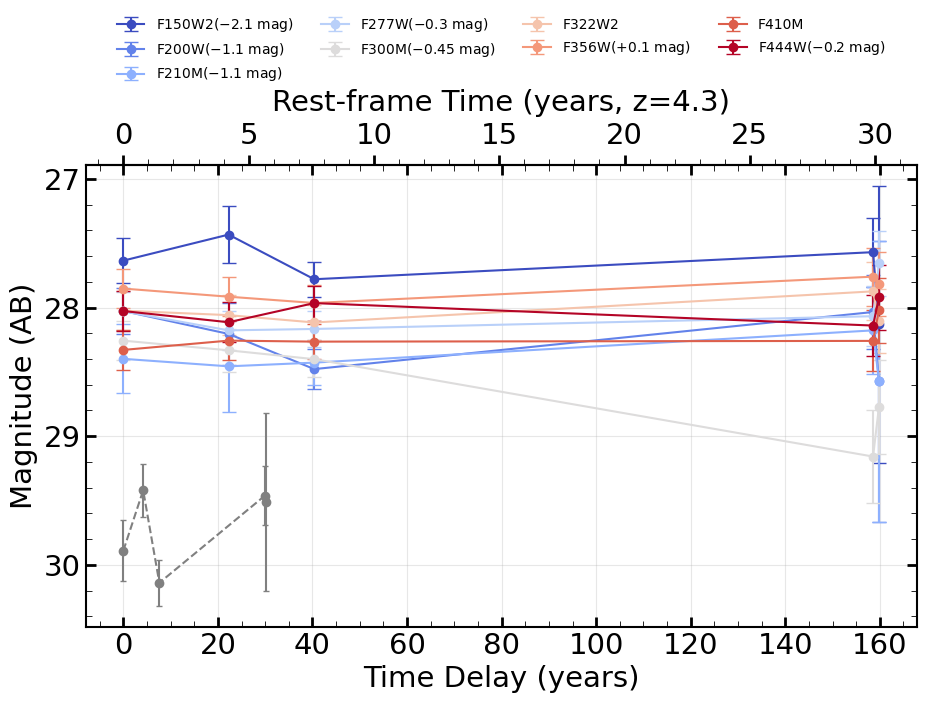

Band            N    chi2       chi2_red   p-value   
SW stack        5    9.517      2.379      0.049     
F150W2          5    2.151      0.538      0.708     
F200W           5    4.448      1.112      0.349     
F210M           5    0.508      0.127      0.973     
F277W           5    3.746      0.936      0.442     
F300M           5    6.410      1.602      0.171     
F322W2          5    0.920      0.230      0.922     
F356W           5    0.807      0.202      0.937     
F410M           5    1.084      0.271      0.897     
F444W           5    0.933      0.233      0.920     

Maximum variability amplitude (Δmag ± err):
F150W2          Δmag = 0.710 ± 1.071
F200W           Δmag = 0.540 ± 1.083
F210M           Δmag = 0.397 ± 1.098
F277W           Δmag = 0.510 ± 0.141
F300M           Δmag = 0.888 ± 0.313
F322W2          Δmag = 0.242 ± 0.117
F356W           Δmag = 0.205 ± 0.118
F410M           Δmag = 0.321 ± 0.144
F444W           Δmag = 0.221 ± 0.140


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import scipy.stats as stats
# from scipy.integrate import simps
from scipy.integrate import simpson as simps

def getlensing_para(src, img_idx):
    mu = lens_dict[f'{src}.{img_idx}']["mu"][0]
    mu_err = np.max([np.abs(lens_dict[f'{src}.{img_idx}']["mu"][2]), np.abs(lens_dict[f'{src}.{img_idx}']["mu"][1])])
    # mu_err = 0.2 * mu
    td = lens_dict[f'{src}.{img_idx}']["dt"][0]
    td_err = np.max([np.abs(lens_dict[f'{src}.{img_idx}']["dt"][2]), np.abs(lens_dict[f'{src}.{img_idx}']["dt"][1])])
    return mu, mu_err, td, td_err
chi2_results = {}
z = 4.3
# 分组
bright_bands = ['F150W2', 'F200W', 'F210M',  'F277W', 'F300M', 'F322W2','F356W', 'F410M', 'F444W']
# faint_bands = ['F090W', 'F115W', 'F150W', 'F200W', 'F210M']
# faint_bands = ['F150W', 'F200W', 'F210M']
faint_bands = ['F090W', 'F115W', 'F150W']
bright_bands_shift = [2.1, 1.1,1.1, 0.3, 0.45,0,-0.1,0,0.2]
bright_flux_keys = ['f_' + b for b in bright_bands]
bright_err_keys = ['e_' + b for b in bright_bands]

faint_flux_keys = ['f_' + b for b in faint_bands]
faint_err_keys = ['e_' + b for b in faint_bands]

plt.figure(figsize=(10,8))
ax = plt.gca()

# 渐变色蓝->红
cmap = get_cmap('coolwarm')
colors_bright = [cmap(i/(len(bright_bands)-1)) for i in range(len(bright_bands))]

# ---- stack 暗 band ----
def get_bandpass_weight(band):
    # 读取滤光片透过率
    file = f'/Users/zijianzhang/Astro_Data/LRD_SPEC/nircam_throughputs/mean_throughputs/{band.upper()}_throughput.txt'
    wave, thr = read_filter_data(file)

    # λ 是 Å，转成 μm (假设你的 photometry 使用 μm)
    wave = wave / 1e4

    # 计算带宽： ∫ T(λ) dλ
    W = simps(thr, wave)
    return W
def read_filter_data(filename):
    data = np.loadtxt(filename, skiprows=1)
    wavelength = data[:, 0]
    throughput = data[:, 1]
    return wavelength, throughput
stack_flux = []
stack_err = []
stack_tdelay = []

# 预先计算所有 band 的带宽权重
bandpass_weights = {b: get_bandpass_weight(b) for b in faint_bands}
total_W = np.sum(list(bandpass_weights.values()))

for i, col in enumerate(sel_tab):

    img_idx = int(col['ID'].split('.')[1])

    mu, mu_err, td, td_err = getlensing_para(10, img_idx)
    mu_err = np.max([0.1 * mu, mu_err])

    flux_list = []
    flux_err_list = []

    for b in range(len(faint_bands)):
        f_obs  = float(col[faint_flux_keys[b]])
        f_err  = float(col[faint_err_keys[b]])
        if(img_idx in [1, 2]):
            f_err = np.sqrt(f_err**2 + (0.2 * f_obs)**2)
        else:
            f_err = np.max([0.1*f_obs, f_err])#
        flux_list.append(f_obs)
        flux_err_list.append(f_err)

    flux_list     = np.array(flux_list)
    flux_err_list = np.array(flux_err_list)

    # ---------- bandpass weighted average ----------
    weights = np.array([bandpass_weights[b] for b in faint_bands])
    flux_stack_obs = np.sum(flux_list * weights) / total_W

    # error propagation
    flux_stack_obs_err = np.sqrt(np.sum((weights / total_W)**2 * flux_err_list**2))

    # de-magnify
    flux_stack_corr = flux_stack_obs / np.abs(mu)

    # mag
    mag_stack = 31.4 - 2.5 * np.log10(flux_stack_corr)

    # error propagation in mag
    mag_stack_err = 2.5/np.log(10) * np.sqrt(
        (flux_stack_obs_err/flux_stack_obs)**2 + (mu_err/np.abs(mu))**2
    )

    stack_flux.append(mag_stack)
    stack_err.append(mag_stack_err)
    stack_tdelay.append(td)

# shift = bright_bands_shift[0]
stack_flux = np.array(stack_flux) #- shift
stack_err = np.array(stack_err)
stack_tdelay = np.array(stack_tdelay)/365/(1+z)
idx_sort = np.argsort(stack_tdelay)
ax.errorbar(stack_tdelay[idx_sort], stack_flux[idx_sort], yerr=stack_err[idx_sort],
            fmt='o--', color='gray', capsize=2)

# ---- stack faint bands ----
weights = 1 / stack_err**2
mean_mag = np.sum(stack_flux * weights) / np.sum(weights)
chi2 = np.sum(((stack_flux - mean_mag)**2) / stack_err**2)
dof = len(stack_flux) - 1
chi2_red = chi2 / dof
p_value = 1 - stats.chi2.cdf(chi2, dof)
chi2_results['SW stack'] = dict(
    N=len(stack_flux),
    chi2=chi2,
    chi2_red=chi2_red,
    p_value=p_value
)

# ---- 先画亮的 band ----
for b, band in enumerate(bright_bands):
    flux_band = []
    flux_err_band = []
    tdelay_band = []
    tdelayerr_band = []
    shift = bright_bands_shift[b]
    for i, col in enumerate(sel_tab):
        img_idx = int(col['ID'].split('.')[1]) 
      
        # mu, mu_err, td, td_err = getlensing_para(9, img_idx)
        # mu_err = np.max([0.2*mu, mu_err])
        mu, mu_err, td, td_err = getlensing_para(10, img_idx)
        mu_err = np.max([0.1*mu, mu_err])   # assign a floor of magnification 
        
        f_obs = float(col[bright_flux_keys[b]])
        f_err_obs = float(col[bright_err_keys[b]])
        # f_err_obs = np.sqrt((0.05 * f_obs)**2 + f_err_obs**2)
        if(img_idx in [1, 2]):
            f_err_obs = np.sqrt(f_err_obs**2 + (0.2 * f_obs)**2)
        else:
            f_err_obs = np.max([0.1*f_obs, f_err_obs])#
        f_corr = f_obs / np.abs(mu)
        mag_corr = 31.4 - 2.5*np.log10(f_corr)
        mag_err = np.sqrt((2.5/np.log(10)*f_err_obs/f_obs)**2 + (2.5/np.log(10)*mu_err/np.abs(mu))**2)

        flux_band.append(mag_corr)
        flux_err_band.append(mag_err)
        tdelay_band.append(td)
        tdelayerr_band.append(td_err)

    flux_band = np.array(flux_band)
    flux_err_band = np.array(flux_err_band)
    tdelay_band = np.array(tdelay_band)/365#/(1+z)
    tdelayerr_band = np.array(tdelayerr_band)/365#/(1+z)
    
    idx_sort = np.argsort(tdelay_band)
    if(shift != 0):
        if(shift > 0):
            text = band + (r'($-$' + f'{np.abs(shift)} mag)')
        else:
            text = band + (r'($+$' + f'{np.abs(shift)} mag)')
        ax.errorbar(tdelay_band[idx_sort], flux_band[idx_sort] - shift,
                    yerr=flux_err_band[idx_sort],
                    fmt='o-', color=colors_bright[b], label=text, capsize=5)
    else:
        ax.errorbar(tdelay_band[idx_sort], flux_band[idx_sort],
                    yerr=flux_err_band[idx_sort],
                    fmt='o-', color=colors_bright[b], label=band, capsize=5)

    # 加权平均作为恒定模型
    weights = 1 / flux_err_band**2
    mean_mag = np.sum(flux_band * weights) / np.sum(weights)

    chi2 = np.sum(((flux_band - mean_mag)**2) / flux_err_band**2)
    dof = len(flux_band) - 1
    chi2_red = chi2 / dof
    p_value = 1 - stats.chi2.cdf(chi2, dof)

    chi2_results[band] = dict(
        N=len(flux_band),
        chi2=chi2,
        chi2_red=chi2_red,
        p_value=p_value
    )


# ---- 画图美化 ----
ax.set_xlabel("Time Delay (years)")
ax.set_ylabel("Magnitude (AB)")
ax.invert_yaxis()
# ax.set_title("System-1 JWST Light Curves (Bright bands + stacked faint bands)")
ax.grid(alpha=0.3)

# 横向 legend
ax.legend(frameon=False, fontsize=10, ncol=4, loc='upper center', bbox_to_anchor=(0.5, 1.35))

# ---- 添加rest-frame时间轴 ----

def obs_to_rest(t_obs):
    return t_obs / (1 + z)

def rest_to_obs(t_rest):
    return t_rest * (1 + z)

secax = ax.secondary_xaxis('top', functions=(obs_to_rest, rest_to_obs))
secax.set_xlabel(f"Rest-frame Time (years, z={z})")
secax.xaxis.labelpad = 8  # 轴标签与图的间距
# ---- 去掉上轴多余的刻度 ----
secax.tick_params(which='both', direction='out', top=True, labeltop=True)
# secax.set_ticks_position('top')  # 确保只在上方显示
# secax.xaxis.set_tick_params(bottom=False)  # 不在下方重复显示
# # 若想让刻度更稀疏（只显示几个）
# secax.set_xticks(np.linspace(*ax.get_xlim(), 5))  # 5个主刻度，可调整数量

plt.tight_layout()
plt.show()

# ---- 输出结果 ----
print(f"{'Band':<15} {'N':<4} {'chi2':<10} {'chi2_red':<10} {'p-value':<10}")
for band, res in chi2_results.items():
    print(f"{band:<15} {res['N']:<4d} {res['chi2']:<10.3f} {res['chi2_red']:<10.3f} {res['p_value']:<10.3f}")

# ---- 计算每个band的最大光变幅度（含误差） ----
print("\nMaximum variability amplitude (Δmag ± err):")
for band, res in chi2_results.items():
    if band == 'SW stack':
        continue  # 跳过stack结果
    flux_band = []
    flux_err_band = []
    for col in sel_tab:
        img_idx = int(col['ID'].split('.')[1])
        if(img_idx == 3):
            img_idx = 4
        elif(img_idx == 4):
            img_idx = 3
        mu, mu_err, td, td_err = getlensing_para(10, img_idx)
        f_obs = float(col['f_' + band])
        f_err_obs = float(col['e_' + band])
        f_corr = f_obs / np.abs(mu)
        mag_corr = 31.4 - 2.5 * np.log10(f_corr)
        mag_err = np.sqrt(
            (2.5 / np.log(10) * f_err_obs / f_obs) ** 2 +
            (2.5 / np.log(10) * mu_err / np.abs(mu)) ** 2
        )

        flux_band.append(mag_corr)
        flux_err_band.append(mag_err)

    flux_band = np.array(flux_band)
    flux_err_band = np.array(flux_err_band)

    idx_max = np.argmax(flux_band)
    idx_min = np.argmin(flux_band)
    delta_mag = flux_band[idx_max] - flux_band[idx_min]
    delta_mag_err = np.sqrt(flux_err_band[idx_max] ** 2 + flux_err_band[idx_min] ** 2)

    print(f"{band:<15} Δmag = {delta_mag:.3f} ± {delta_mag_err:.3f}")

In [34]:
import numpy as np
import emcee
from scipy.optimize import minimize

def estimate_intrinsic_variability(x, sig_i):
    """
    使用 MCMC 采样计算固有变率 sigma_0 的后验分布
    x: 观测星等数组
    sig_i: 观测误差数组
    返回: sigma_0 (中位数), sigma_0_err (1-sigma对称化), mean_sig_i
    """
    x = np.array(x)
    sig_i = np.array(sig_i)
    
    # 1. 定义对数似然函数 (Log-Likelihood)
    def log_likelihood(theta, x, sig_i):
        mu, s0 = theta
        if s0 < 0:  # 强加先验：sigma_0 必须大于0
            return -np.inf
        variance = s0**2 + sig_i**2
        return -0.5 * np.sum(((x - mu)**2 / variance) + np.log(variance))

    # 2. 寻找极大似然估计 (MLE) 作为 MCMC 的起点
    nll = lambda *args: -log_likelihood(*args)
    initial = np.array([np.mean(x), np.std(x)])
    soln = minimize(nll, initial, args=(x, sig_i), bounds=[(None, None), (1e-6, None)])
    
    # 3. MCMC 设置
    nwalkers = 32
    ndim = 2
    # 在 MLE 结果附近播种初始位置
    pos = soln.x + 1e-4 * np.random.randn(nwalkers, ndim)
    
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood, args=(x, sig_i))
    
    # 运行 Burn-in 和正式采样
    sampler.run_mcmc(pos, 1500, progress=False)
    
    # 获取平稳后的样本 (去掉前 300 步 burn-in)
    flat_samples = sampler.get_chain(discard=300, thin=15, flat=True)
    
    # 4. 提取结果 (使用分位数提取 sigma_0)
    # sigma_0 是第 2 列 (index 1)
    s0_mcmc = np.percentile(flat_samples[:, 1], [16, 50, 84])
    s0_mcmc_3sigma = np.percentile(flat_samples[:, 1], [0.135, 50, 99.865])
    
    # sigma_0_med = s0_mcmc[1]
    # 使用 1-sigma 的平均值作为对称误差
    # sigma_0_err = (s0_mcmc[2] - s0_mcmc[0]) / 2.0
    
    mean_sig_i = np.mean(sig_i)
    
    # return sigma_0_med, sigma_0_err, mean_sig_i
    return s0_mcmc , s0_mcmc_3sigma , mean_sig_i

/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_27929/1295812314.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('RdBu')
/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_27929/1295812314.py:97: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=9, loc='best')
/Users/zijianzhang/miniconda3/envs/msaexp39/lib/python3.9/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
/var/folders/gn/sbp9fx457qz90df4d6_4rsk80000gn/T/ipykernel_27929/1295812314.py:239: UserWarning: No artists with labels found to put in legend.  Note that artists wh

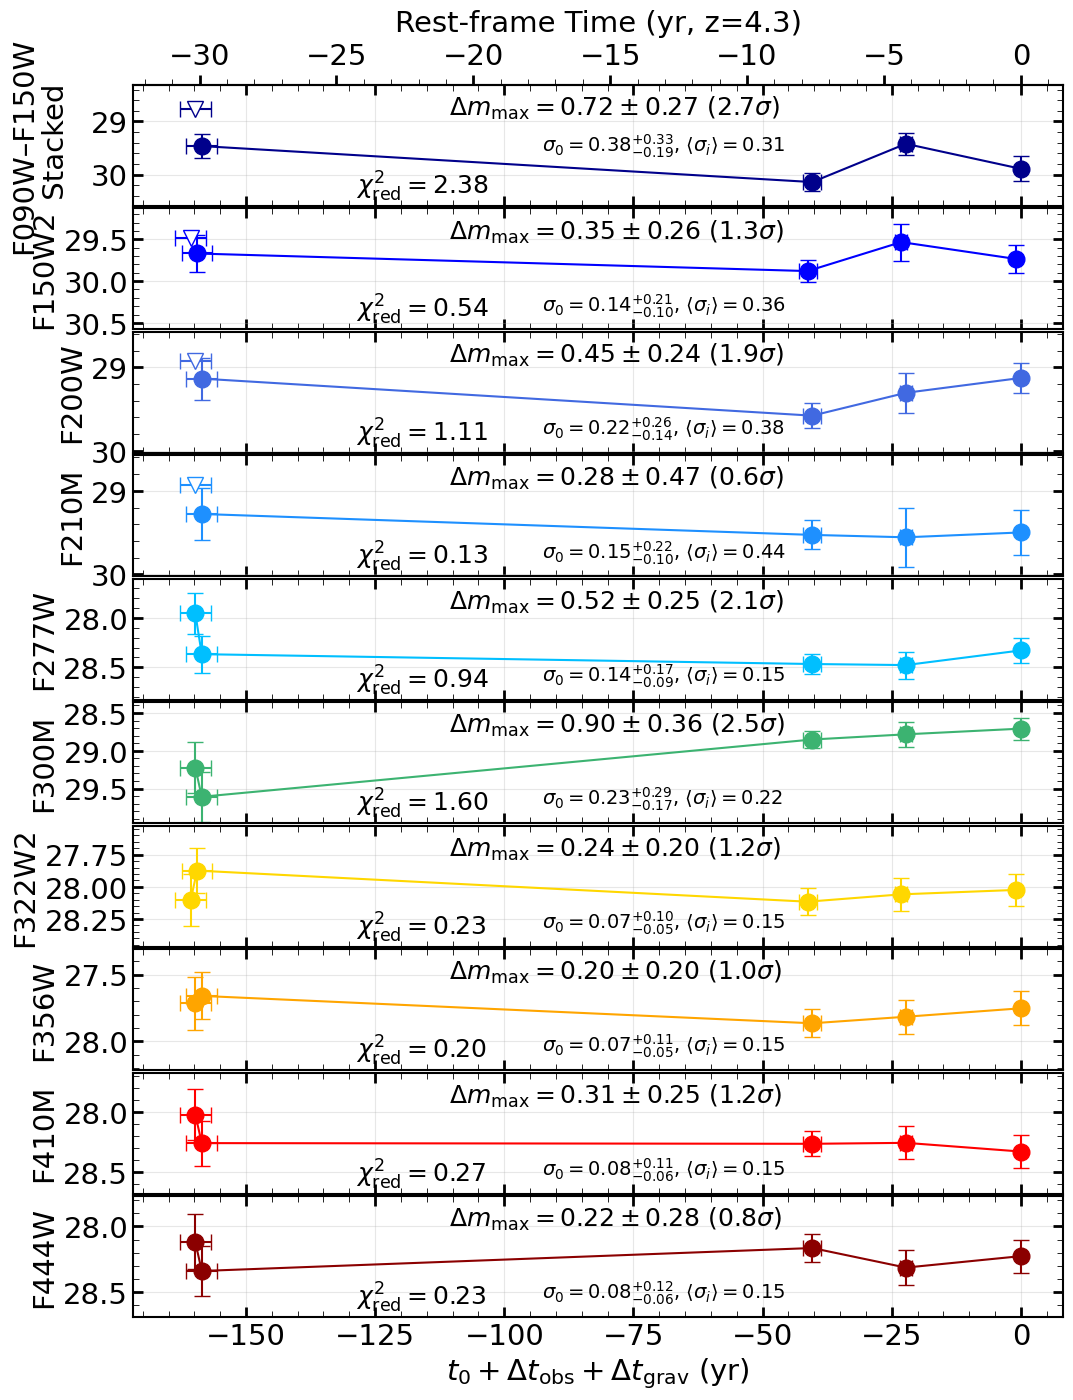

In [38]:
# ---- 假设这些变量已定义 ----
# bright_bands, bright_bands_shift, stack_tdelay, stack_flux, stack_err, z, sel_tab, systems_data, mu_errs

# ---- 配色 ----
cmap = get_cmap('RdBu')
# colors_bright = [cmap(i/(len(bright_bands)-1)) for i in range(len(bright_bands))]
colors_bright = [
        # 最短波
    'blue',        # 
    'royalblue',   # 
    'dodgerblue',  # 
    'deepskyblue', # 
    # 'cyan',        # 
    'mediumseagreen', # 中间波段用绿色区分
    'gold',        # 
    'orange',      # 
    'red',         # 
    'darkred'      # 最长波
]
symbolsize = 12
# ---- 创建子图 (stack + bright bands) ----
n_panels = len(bright_bands) + 1
fig, axes = plt.subplots(n_panels, 1, figsize=(12, 1.6 * n_panels), sharex=True)
if n_panels == 1:
    axes = [axes]

color = 'darkblue'
# ===============================================================
# (1) 绘制 stacked faint bands
# ===============================================================
ax = axes[0]
is_upper = stack_err > 0.4
is_normal = ~is_upper

mask = ~np.isnan(stack_flux) & ~np.isnan(stack_err)
clean_flux = stack_flux[mask]
clean_err = stack_err[mask]

# sigma_0, sigma_0_err, avg_sig_i = estimate_intrinsic_variability(clean_flux, clean_err)
(sigma_0_down, sigma_0, sigma_0_up),_, avg_sig_i = estimate_intrinsic_variability(clean_flux, clean_err)
# --- 绘图标注 ---
# 替换原来的 chi2 标注，或者在其下方添加
# ml_text = (r"$\sigma_0 = %.2f \pm %.2f$" % (sigma_0, sigma_0_err) + "\n" +
        #    r"$\langle \sigma_i \rangle = %.2f$" % (avg_sig_i))
ml_text = (r"$\sigma_0 = %.2f^{+%.2f}_{-%.2f}$" % (sigma_0, sigma_0_up - sigma_0, sigma_0 - sigma_0_down) + #"\n" +
       r", $\langle \sigma_i \rangle = %.2f$" % (avg_sig_i))
ax.text(0.44, 0.45, ml_text, fontsize=14, transform=ax.transAxes)

# --- 正常点 ---
ax.errorbar(
    -tdelay_band[idx_sort][is_normal[idx_sort]],
    stack_flux[idx_sort][is_normal[idx_sort]],
    xerr=tdelayerr_band[idx_sort][is_normal[idx_sort]],
    yerr=stack_err[idx_sort][is_normal[idx_sort]],
    fmt='o-',
    color=color,
    capsize=6,
    markersize=symbolsize
)
# --- upper limit 点 ---
ax.errorbar(
    -tdelay_band[idx_sort][is_upper[idx_sort]],
    stack_flux[idx_sort][is_upper[idx_sort]] - 0.75,
    xerr=tdelayerr_band[idx_sort][is_upper[idx_sort]],
    uplims=True,             # 向下箭头
    fmt='v',                 # 倒三角形
    color=color,
    markersize=symbolsize,
    mfc='white',             # 空心
    mec=color,
    capsize=6
)
# ax.text(0.64, 0.75, r'$\Delta m_{\rm max} = %.2f \pm %.2f$' % (delta_mag, delta_mag_err), fontsize = 18, transform=ax.transAxes)
# 只用非上限点计算 Δm
valid = ~is_upper & np.isfinite(stack_flux) & np.isfinite(stack_err)
if np.sum(valid) >= 2:
    idx_max = np.argmax(stack_flux[valid])
    idx_min = np.argmin(stack_flux[valid])
    delta_mag = stack_flux[valid][idx_max] - stack_flux[valid][idx_min]
    delta_mag_err = np.sqrt(
        stack_err[valid][idx_max]**2 + stack_err[valid][idx_min]**2
    )
    nsigma = np.abs(delta_mag) / delta_mag_err

    ax.text(
        0.34, 0.75,
        r'$\Delta m_{\rm max} = %.2f \pm %.2f\ (%.1f\sigma)$' 
        % (delta_mag, delta_mag_err, nsigma),
        fontsize=18, transform=ax.transAxes
    )
    
chi = chi2_results['SW stack']['chi2_red']
ax.text(0.24, 0.1, r'$\chi^2_{\rm red} = %.2f $' % (chi ), fontsize = 18, transform=ax.transAxes)

ax.invert_yaxis()
ax.grid(alpha=0.3)
ax.legend(frameon=False, fontsize=9, loc='best')
ax.set_ylabel('F090W–F150W\n Stacked', labelpad =15)
# ax.set_title("System-1 JWST Light Curves")


mean_stack = np.nanmean(stack_flux)
if(np.sum(~valid) >= 1):
    min_stack = min(np.nanmin(stack_flux[valid]), np.nanmin(stack_flux[~valid] - 0.75))
else:
    min_stack = np.nanmin(stack_flux[valid])
max_stack = np.nanmax(stack_flux)
y_half_range = 0.45
ax.set_ylim(max_stack + y_half_range, min_stack - y_half_range)

# ===============================================================
# (2) 绘制每个 bright band
# ===============================================================
for b, band in enumerate(bright_bands):
    ax = axes[b+1]
    shift = bright_bands_shift[b]
    color = colors_bright[b]

    flux_band = []
    flux_err_band = []
    tdelay_band = []

    for i, col in enumerate(sel_tab):
        img_idx = int(col['ID'].split('.')[1])
        
        mu, mu_err, td, td_err = getlensing_para(10, img_idx)
        mu_err = np.max([0.1*mu, mu_err])
        
        f_obs = float(col['f_' + band])
        f_err_obs = float(col['e_' + band])
        if(img_idx in [1, 2]):
            f_err_obs = np.sqrt(f_err_obs**2 + (0.15 * f_obs)**2)
        else:
            f_err_obs = np.max([0.06*f_obs, f_err_obs])#
        
        f_corr = f_obs / np.abs(mu)
        mag_corr = 31.4 - 2.5 * np.log10(f_corr)
        mag_err = np.sqrt((2.5/np.log(10)*f_err_obs/f_obs)**2 +
                          (2.5/np.log(10)*mu_err/np.abs(mu))**2)

        flux_band.append(mag_corr)
        flux_err_band.append(mag_err)
        tdelay_band.append(td)

    flux_band = np.array(flux_band)
    flux_err_band = np.array(flux_err_band)
    tdelay_band = np.array(tdelay_band)/365
    idx_sort = np.argsort(tdelay_band)
    idx_max = np.argmax(flux_band)
    idx_min = np.argmin(flux_band)
    delta_mag = flux_band[idx_max] - flux_band[idx_min]
    delta_mag_err = np.sqrt(flux_err_band[idx_max] ** 2 + flux_err_band[idx_min] ** 2)

    mask = ~np.isnan(flux_band) & ~np.isnan(flux_err_band)
    clean_flux = flux_band[mask]
    clean_err = flux_err_band[mask]
    
    # sigma_0, sigma_0_err, avg_sig_i = estimate_intrinsic_variability(clean_flux, clean_err)
    (sigma_0_down, sigma_0, sigma_0_up),_, avg_sig_i = estimate_intrinsic_variability(clean_flux, clean_err)

    # --- 绘图标注 ---
    # 替换原来的 chi2 标注，或者在其下方添加
    # ml_text = (r"$\sigma_0 = %.2f \pm %.2f$" % (sigma_0, sigma_0_err) + "\n" +
            #    r"$\langle \sigma_i \rangle = %.2f$" % (avg_sig_i))
    ml_text = (r"$\sigma_0 = %.2f^{+%.2f}_{-%.2f}$" % (sigma_0, sigma_0_up - sigma_0, sigma_0 - sigma_0_down) + #"\n" +
           r", $\langle \sigma_i \rangle = %.2f$" % (avg_sig_i))
    
    ax.text(0.44, 0.15, ml_text, fontsize=14, transform=ax.transAxes)
            
    # 绘制该band光变曲线
    if('W2' in band):
        tdelay_band += 0.9
    # ax.errorbar(
    #     -tdelay_band[idx_sort],
    #     flux_band[idx_sort], #- shift,
    #     yerr=flux_err_band[idx_sort],
    #     fmt='o-',
    #     color=color,
    #     capsize=6,
    #     markersize = symbolsize
    #     # label=band #if shift == 0 else f"{band} ({'-' if shift>0 else '+'}{abs(shift)} mag)"
    # )
    # 计算信噪比（在mag空间中，定义S/N = 1/mag_err的粗略近似）
    # snr = 1 / flux_err_band
    is_upper = flux_err_band > 0.4
    is_normal = ~is_upper
    
    # --- 正常点 ---
    ax.errorbar(
        -tdelay_band[idx_sort][is_normal[idx_sort]],
        flux_band[idx_sort][is_normal[idx_sort]],
        xerr=tdelayerr_band[idx_sort][is_normal[idx_sort]],
        yerr=flux_err_band[idx_sort][is_normal[idx_sort]],
        fmt='o-',
        color=color,
        capsize=6,
        markersize=symbolsize
    )
    
    # --- upper limit 点 ---
    ax.errorbar(
        -tdelay_band[idx_sort][is_upper[idx_sort]],
        flux_band[idx_sort][is_upper[idx_sort]] - 0.75,
        xerr=tdelayerr_band[idx_sort][is_upper[idx_sort]],
        yerr=None,
        uplims=True,             # 向下箭头
        fmt='v',                 # 倒三角形
        color=color,
        markersize=symbolsize,
        mfc='white',             # 空心
        mec=color,
        capsize=6
    )
    # if()
    # ax.text(0.64, 0.75, r'$\Delta m_{\rm max} = %.2f \pm %.2f$' % (delta_mag, delta_mag_err), fontsize = 18, transform=ax.transAxes)
    # 只用非上限点计算 Δm
    valid = ~is_upper & np.isfinite(flux_band) & np.isfinite(flux_err_band)
    if np.sum(valid) >= 2:
        idx_max = np.argmax(flux_band[valid])
        idx_min = np.argmin(flux_band[valid])
        delta_mag = flux_band[valid][idx_max] - flux_band[valid][idx_min]
        delta_mag_err = np.sqrt(
            flux_err_band[valid][idx_max]**2 + flux_err_band[valid][idx_min]**2
        )
    nsigma = np.abs(delta_mag) / delta_mag_err

    ax.text(
        0.34, 0.75,
        r'$\Delta m_{\rm max} = %.2f \pm %.2f\ (%.1f\sigma)$' 
        % (delta_mag, delta_mag_err, nsigma),
        fontsize=18, transform=ax.transAxes
    )
    
    chi = chi2_results[band]['chi2_red']
    ax.text(0.24, 0.1, r'$\chi^2_{\rm red} = %.2f $' % (chi ), fontsize = 18, transform=ax.transAxes)

    ax.invert_yaxis()
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, fontsize=9, loc='best')

    ax.set_ylabel(band)

    # ---- 每个band围绕自身平均值设定y轴范围 ----
    mean_stack = np.nanmean(flux_band)
    if(np.sum(~valid) >= 1):
        min_stack = min(np.nanmin(flux_band[valid]), np.nanmin(flux_band[~valid]- 0.75))
    else:
        min_stack = np.nanmin(flux_band[valid])
    max_stack = np.nanmax(flux_band)
    y_half_range = 0.35
    ax.set_ylim(max_stack + y_half_range, min_stack - y_half_range)
# ===============================================================
# (3) 共用x轴 + rest-frame secondary axis
# ===============================================================
axes[-1].set_xlabel(r"$t_0 + \Delta t_{\rm obs} + \Delta t_{\rm grav}$" + " (yr)")

def obs_to_rest(t_obs):
    return t_obs / (1 + z)
def rest_to_obs(t_rest):
    return t_rest * (1 + z)

secax = axes[0].secondary_xaxis('top', functions=(obs_to_rest, rest_to_obs))
secax.set_xlabel(f"Rest-frame Time (yr, z={z})")
secax.xaxis.labelpad = 8
secax.tick_params(which='both', direction='out', top=True, labeltop=True)

# plt.tight_layout()
plt.subplots_adjust(hspace=0.02)  # 调小子图间距，原默认≈0.2–0.3
plt.savefig('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/' + 'RX2_lc.pdf', dpi=200, bbox_inches='tight',pad_inches=0.2)
plt.show()

Duplicate key in file '/Users/zijianzhang/Astro_Data/paper.mplstyle', line 23 ('axes.linewidth : 1.5')


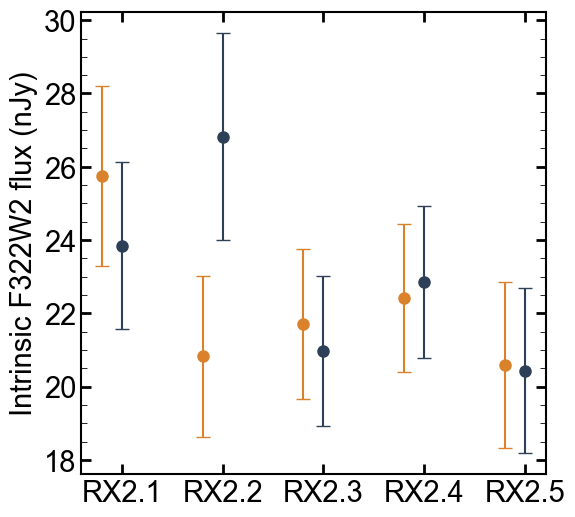

In [40]:
plt.style.use('/Users/zijianzhang/Astro_Data/paper.mplstyle')
plt.rcParams['font.sans-serif'] = ['Arial']

t = np.array([1,2,3,4,5])
mulist = np.abs(np.array([getlensing_para(10, img_idx)[0] for img_idx in t]))
muerrlist = np.array([getlensing_para(10, img_idx)[1] for img_idx in t])

# 设 5% floor
rel_obs_err = np.maximum(sel_tab['e_F322W2'] / sel_tab['f_F322W2'], 0.08)
obs_F322W2_f = sel_tab['f_F322W2']/mulist
obs_F322W2_e = obs_F322W2_f * np.sqrt(
    (rel_obs_err)**2 +
    (muerrlist / mulist)**2
)


syn_raw_f = (sel_tab['f_F277W'] + sel_tab['f_F356W']) / 2
syn_raw_e = np.sqrt(sel_tab['e_F277W']**2 + sel_tab['e_F356W']**2)
rel_syn_err = np.maximum(syn_raw_e / syn_raw_f, 0.08)  # 5% floor


syn_F322W2_f = syn_raw_f / mulist
syn_F322W2_e = syn_F322W2_f * np.sqrt(
    (rel_syn_err)**2 +
    (muerrlist / mulist)**2
)

fig = plt.figure(figsize = (6,6))
plt.errorbar(t, syn_F322W2_f, yerr = syn_F322W2_e,  color = '#2E4057', fmt='o', markersize=8, capsize=5)
plt.errorbar(t - 0.2, obs_F322W2_f , yerr = obs_F322W2_e,color = '#D9822B', fmt='o', markersize=8, capsize=5)
plt.ylabel('Intrinsic F322W2 flux (nJy)')
x_ticks = [ 1, 2, 3, 4, 5]
plt.gca().set_xticks(x_ticks)
plt.gca().set_xticklabels(['RX2.' + str(int(tick)) if tick < 10 else f"{int(tick)}" for tick in x_ticks])
# 如果你只想关 X 轴 minor，保留 Y 轴 minor：
plt.gca().xaxis.set_minor_locator(plt.NullLocator())  # 关闭X轴minor
# plt.savefig()
# plt.savefig('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/' + 'venus_slice_RX2.pdf', dpi=200, bbox_inches='tight')


In [41]:
np.abs((obs_F322W2_f - syn_F322W2_f)) / np.sqrt(syn_raw_e**2 + obs_F322W2_e**2)

0.6472699433434409
2.0601156523490824
0.11854820527075524
0.07265696951804841
0.013092211914584689


In [46]:
list((2.5 / np.log(10)) * np.sqrt((obs_F322W2_e/obs_F322W2_f)**2 + (syn_F322W2_e/syn_F322W2_f)**2))

[0.14665171350254846,
 0.16184191623693112,
 0.14756547921109203,
 0.1386767388651078,
 0.1693597584645844]

In [42]:
dmag = -2.5 * np.log10(obs_F322W2_f / syn_F322W2_f)
dmag

-0.08284723335446581
0.27415105154848535
-0.037879349808110974
0.021296532676286554
-0.008211986120468067


In [19]:
dmag.tolist()

[-0.08284723335446581,
 0.27415105154848535,
 -0.037879349808110974,
 0.021296532676286554,
 -0.008211986120468067]

In [47]:
rel_syn_err

0.05755341123080456
0.06951691240030237
0.08374336059623812
0.07552068192886406
0.07325000129166441


In [19]:
flux_band

array([28.3394446 , 28.11870043, 28.30073866, 28.23949498, 28.16482682])

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u, constants as const
from astropy.cosmology import Planck18 as cosmo

def blackbody_Fnu(wavelengths_um, T, logLbol, z = 4.8):
    """
    返回观测到的黑体 Fν (单位: nJy)

    参数:
        wavelengths_um : array
            观测波长 (μm)
        T : float
            黑体温度 (K)
        z : float
            红移
        Lbol : float
            总光度 (erg/s)
    """
    # 常量
    h = const.h.cgs
    c = const.c.cgs
    kB = const.k_B.cgs
    sigma = const.sigma_sb.cgs

    # ---- 波长、频率 ----
    wave_obs = wavelengths_um * u.um
    wave_rest = wave_obs / (1 + z)
    nu_rest = (c / wave_rest).to(u.Hz)

    # ---- 黑体比辐射强度 (erg s⁻¹ cm⁻² Hz⁻¹ sr⁻¹) ----
    Bnu = (2 * h * nu_rest**3 / c**2) / (np.expm1(h * nu_rest / (kB * T * u.K)))
    Bnu *= 4 * np.pi  # 各向同性积分立体角

    # ---- 由 Lbol 推出半径 ----
    Lbol = 10**logLbol * u.erg / u.s
    R = np.sqrt(Lbol / (4 * np.pi * sigma * (T * u.K)**4))

    # 本征光度谱 Lν = 4πR² Bν
    Lnu = 4 * np.pi * R**2 * Bnu  # erg/s/Hz

    # ---- 光度距离与红移衰减 ----
    DL = cosmo.luminosity_distance(z).to(u.cm)
    Fnu = Lnu / (4 * np.pi * DL**2) / (1 + z)  # erg/s/cm²/Hz

    return Fnu.to(u.nJy).value



1.1: T=3500 ± 838 K, norm=43.39
1.2: T=3606 ± 670 K, norm=43.50
1.3: T=4740 ± 1787 K, norm=43.35
1.4: T=4945 ± 1446 K, norm=43.37
共用 power-law 振幅: A_PL = 6.547, 指数 alpha = -0.295, A_V = 0.50


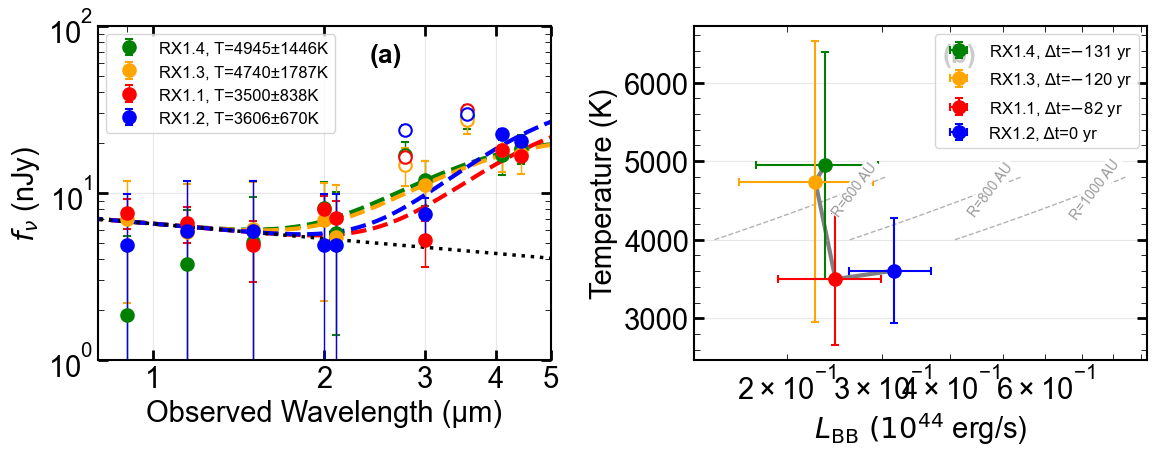

In [92]:
import extinction
from scipy.optimize import curve_fit
from scipy.stats import linregress
# ===== 用户需提供的数据 =====
# wave_jwst: 波长数组，单位 µm
# jwstflux_list: 长度4列表，每个元素为 flux 数组 (nJy)
# jwstfluxerr_list: flux 不确定度
# lens_dict: 含时间延迟 td
# blackbody_Fnu(wavelength, T, norm) 已定义

colors = ['green','orange', 'red','blue'  ]
blue_cut = 1.0     # µm，仅用于标记蓝端
redshift = 4.3
AV_adopted = 0.5
# ===== 联合模型函数 =====
def joint_model_allbands(wavelengths_all, *params):
    """
    wavelengths_all: list of 4 arrays, 每个像的波长
    params: [T1,norm1, T2,norm2, T3,norm3, T4,norm4, A_PL, alpha, A_V]
    返回拼接后的 flux (已考虑统一的尘埃吸收)
    """
    flux_model_all = []
    # A_PL = params[-3]   # 共用 power-law 振幅
    # alpha = params[-2]  # 共用 power-law 指数
    # A_V = params[-1]    # 统一的消光参数
    A_PL = params[-2]   # 共用 power-law 振幅
    alpha = params[-1]  # 共用 power-law 指数
    A_V = AV_adopted

    for i, wl in enumerate(wavelengths_all):
        # wl 单位 µm → 转为 Å 供 extinction 使用
        wl_AA = wl * 1e4

        T = params[2*i]
        norm = params[2*i+1]

        # 本征黑体 + 功率律
        flux_bb = blackbody_Fnu(wl, T, norm, z=redshift)
        A_lambda = extinction.calzetti00(wl_AA/(1+redshift), A_V, r_v=4.05)
        flux_pl = A_PL * (wl/blue_cut)**alpha
        flux_int = flux_bb * 10**(-0.4 * A_lambda) + flux_pl

        # Calzetti extinction (A_lambda in mag)
        
        flux_obs = flux_int
        flux_model_all.append(flux_obs)

    return np.concatenate(flux_model_all)
# ===== 准备数据 =====
#1.3 与 1.4是相反的！
wavelengths_all = [wave_jwst[2:].value for _ in range(4)]
fluxes_all = np.concatenate([jwstflux_list[i][2:] for i in range(4)])
fluxerrs_all = np.concatenate([jwstfluxerr_list[i][2:]for i in range(4)])

# ===== 初始猜测和边界 =====
params0 = []
for _ in range(4):
    params0 += [4700, 43.5]  # T, norm
params0 += [0.5, -0.5]  # A_PL, alpha, A_V

lower_bounds = [3500, 40]*4 + [0.0, -3.0]
upper_bounds = [6000, 45]*4 + [100.0, 1.0]  # A_V 上限可根据需要调整

# ===== 联合拟合 =====
popt, pcov = curve_fit(joint_model_allbands, wavelengths_all, fluxes_all,
                       p0=params0, sigma=fluxerrs_all,
                       bounds=(lower_bounds, upper_bounds))

# ===== 提取结果 =====
fit_results = {}
# A_PL, alpha = popt[-2], popt[-1]
# print(f"共用 power-law 振幅: A_PL = {A_PL:.3f}, 指数 alpha = {alpha:.3f}")
for i in range(4):
    T = popt[2*i]
    norm = popt[2*i+1]
    T_err = np.sqrt(pcov[2*i, 2*i])
    norm_err = np.sqrt(pcov[2*i+1, 2*i+1])
    td = lens_dict[f'9.{i+1}']["dt"][0]
    fit_results[f'1.{i+1}'] = {'temperature': T, 'temperature_err': T_err, 'norm': norm, 'norm_err': norm_err, 'td': td}
    print(f'1.{i+1}: T={T:.0f} ± {T_err:.0f} K, norm={norm:.2f}')
# A_PL, alpha, A_V = popt[-3], popt[-2], popt[-1]
A_PL, alpha, A_V = popt[-2], popt[-1], AV_adopted
print(f"共用 power-law 振幅: A_PL = {A_PL:.3f}, 指数 alpha = {alpha:.3f}, A_V = {A_V:.2f}")

# ===== 绘图 =====
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,5))

fit_wave = np.linspace(0.3,5.0,300)
# --- 左图: SED + 拟合 + power-law ---
cori = 0
for i in np.array([4,3,1,2]) - 1:
    wl = wave_jwst.value
    flux = jwstflux_list[i]#.value
    fluxerr = jwstfluxerr_list[i]#.value
    T = fit_results[f'1.{i+1}']['temperature']
    T_err = fit_results[f'1.{i+1}']['temperature_err']
    norm = fit_results[f'1.{i+1}']['norm']
    norm_err = fit_results[f'1.{i+1}']['norm_err']
    color = colors[cori]
    cori +=1

    # flux_bb = blackbody_Fnu(fit_wave, T, norm, z = redshift)
    # flux_pl = A_PL * (fit_wave/blue_cut)**alpha
    # fit_flux = flux_bb + flux_pl
    A_lambda = extinction.calzetti00(fit_wave/(1+redshift) * 1e4, A_V, r_v=4.05)
    flux_bb = blackbody_Fnu(fit_wave, T, norm, z=redshift)
    flux_pl = A_PL * (fit_wave/blue_cut)**alpha
    flux_int = flux_bb * 10**(-0.4 * A_lambda) + flux_pl
    # flux_int = flux_bb + flux_pl

    # 加入消光（Calzetti曲线）
   
    fit_flux = flux_int 

    cutoff = -8
    ax1.errorbar(wl[:cutoff], flux[:cutoff], yerr=fluxerr[:cutoff],
                 fmt='o', ms=9, color=color, mfc='white', mew=1.5,
                 elinewidth=1, capsize=3)
    ax1.errorbar(wl[cutoff:], flux[cutoff:], yerr=fluxerr[cutoff:],
                 fmt='o', ms=9, color=color, mew=1.5,
                 elinewidth=1, capsize=3,
                 label=f'RX1.{i+1}, T={T:.0f}±{T_err:.0f}K')

    # 总SED曲线（黑体+powerlaw）
    ax1.plot(fit_wave, fit_flux, '--', color=color, alpha=1.0, lw=3)
    # power-law单独虚线（可选）

ax1.plot(fit_wave, flux_pl, ':', color='k', alpha=1, lw=2.5)

# 左图设置
ax1.set_xlabel("Observed Wavelength (µm)")
ax1.set_ylabel(r"$f_{\nu}$ (nJy)")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim(0.8, 5)
ax1.set_ylim(1, 1e2)
ax1.grid(True, alpha=0.3)
x_ticks = [ 1, 2, 3, 4,5]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([str(int(tick)) if tick < 10 else f"{int(tick)}" for tick in x_ticks])
ax1.legend(fontsize=12)

# --- 右图: T vs Lbol ---
sorted_items = sorted(fit_results.items(), key=lambda x: -x[1]['td'])
names = [k for k,_ in sorted_items]
temps = np.array([v['temperature'] for _,v in sorted_items])
temp_errs = np.array([v['temperature_err'] for _,v in sorted_items])
logs_Lbol = np.array([v['norm'] for _,v in sorted_items])
logs_Lbol_errs = np.array([v['norm_err'] for _,v in sorted_items])
tds = np.array([v['td'] for _,v in sorted_items])

# 转换为线性 L 及误差
L = 10**logs_Lbol
L_err = np.log(10) * L * logs_Lbol_errs

for i, (Lval, Lerr, T, Terr, td, name) in enumerate(zip(L, L_err, temps, temp_errs, tds, names)):
    color = colors[i]
    if i!=3:
        sign = r'$-$' 
    else:
        sign = ''
    ax2.errorbar(Lval/1e44, T, 
                 xerr=Lerr/1e44, yerr=Terr,
                 fmt='o', color=color,
                 ms=9, mew=1.5, capsize=3,
                 label=f'RX{name}, Δt=' + sign + f'{td/365:.0f} yr')
# 指定连线顺序
order = [3, 2, 1, 0]  # Python索引，从0开始
L_ordered = np.array(10**logs_Lbol)[order] / 1e44
T_ordered = np.array(temps)[order]

# 连线
ax2.plot(L_ordered, T_ordered, '-', color='gray', lw=3, zorder=-1)  # zorder=-1 放在点的下方
# log-log 拟合
slope, intercept, r_value, p_value, stderr = linregress(np.log10(temps), logs_Lbol)
t_fit = np.linspace(4000,4800,100)
L_fit = 10**intercept * t_fit**slope
# ax2.plot(L_fit/1e44, t_fit, 'k--', lw=2, label=r'$L \propto T^{%.1f}$' % slope)

# 理论半径

sigma = const.sigma_sb.cgs.value
for R_AU in [ 600, 800, 1000]:
    R_cm = (R_AU * u.AU).to(u.cm).value
    L_theory = 4 * np.pi * sigma * R_cm**2 * t_fit**4  # erg/s
    ax2.plot(L_theory/1e44, t_fit, '--', color='gray', lw=1.0, alpha=0.6, zorder=0)

    # 获取线的中间位置
    mid = len(t_fit) // 5 * 4
    x_mid = L_theory[mid]
    y_mid = t_fit[mid]

    # 沿着线的斜率旋转文字
    dx = np.log10(L_theory[mid+1]) - np.log10(L_theory[mid-1])
    dy = t_fit[mid+1] - t_fit[mid-1]
    angle = 53#np.degrees(np.arctan2(dy, dx * np.log(10)))
    
    ax2.text(
    x_mid/1e44, y_mid, f"R={R_AU} AU",
    color='gray', fontsize=10, alpha=0.8,
    rotation=angle, rotation_mode='anchor',
    ha='center', va='center',
    bbox=dict(facecolor='white', edgecolor='none', alpha=1, pad=1.5)
)

ax2.set_xscale('log')
ax2.set_xlabel(r"$L_{\rm BB}~ (10^{44}$ erg/s)")
ax2.set_ylabel("Temperature (K)")
# ax2.set_xlim(1.4,5)

ax2.grid(True, alpha=0.3)
# x_ticks = [ 2,3,4,5]#,6,7
# ax2.set_xticks(x_ticks)
# ax2.set_xticklabels([str(t) for t in x_ticks])
ax2.legend(fontsize=12, loc=0)

ax1.text(0.6, 0.95, f'(a)', color='k', fontsize=19, transform=ax1.transAxes, ha='left', va='top', weight='bold')
ax2.text(0.55, 0.95, f'(b)', color='k', fontsize=19, transform=ax2.transAxes, ha='left', va='top', weight='bold')
plt.tight_layout()
# plt.savefig('/Users/zijianzhang/Astro_Data/multi-image_LRD_cluster/RXCJ2211/figure/' + 'RX1_BBfit.pdf', dpi=200, bbox_inches='tight')
# plt.show()

In [17]:
# --- Bootstrap ---
n_boot = 100000
rng = np.random.default_rng()

# 对每个数据点按其误差进行随机采样（假设误差为高斯分布）
L_samples = rng.normal(loc=L, scale=L_err, size=(n_boot, len(L)))

# 计算每次采样的 median
medians = np.median(L_samples, axis=1)

# 取最终 median 和 1σ 置信区间（非对称）
median_L = np.median(medians)
low1, high1 = np.percentile(medians, [16, 84])

err_low = median_L - low1
err_high = high1 - median_L

print(f"Median L = {median_L:.3e}")
print(f"Median error = -{err_low:.3e}  +{err_high:.3e}")

Median L = 2.535e+43
Median error = -3.279e+42  +3.228e+42


In [22]:
jwstflux_list

[array([16.34188536, 31.35755261,  4.88317355,  7.6260941 ,  6.61031507,
         8.05938977,  7.06678957,  5.2088537 , 18.05103713, 16.75799898]),
 array([23.86051583, 29.77966639,  5.88235294,  4.90196078,  5.88235294,
         4.90196078,  4.90196078,  7.43840513, 22.47811187, 20.53618785]),
 array([14.76657779, 27.1636211 ,  6.07367039,  6.9613084 ,  5.83268179,
         6.89046373,  5.46255595, 11.1477839 , 18.08777777, 17.16067252]),
 array([16.92116626, 28.79121683,  5.06644433,  1.86743839,  3.74178739,
         8.11959236,  5.76379757, 11.94606723, 16.92175813, 18.59397502]),
 array([14.91387353, 25.96807992,  3.67958842,  2.34175194,  2.95207169,
         5.35492426,  5.60924333, 10.46463788, 17.95669891, 19.68200206])]